# Non-Invasive BGL Estimation: Khan 2026 APG Pulse Ratio Integration Experiment
**GlucoSense Primary Dataset (Nigerian T2DM Cohort)**  
*Author: FYP Research Team | Healthcare AI & Biomedical Signal Processing*

---

## 🧪 Experiment Objective
In Khan et al. (2026), APG wave ratios computed **pulse-by-pulse** across cardiac cycles showed high correlation with Blood Glucose Levels (BGL).  
In this experiment, we integrate the exact Khan 2026 pulse-by-pulse APG wave ratio extraction formulas into our real data pipeline:
- $b/a$: Early systolic wave ratio
- $c/a$: Late systolic wave ratio
- $d/a$: Dicrotic notch ratio
- $e/a$: Diastolic wave ratio
- $(b-c-d-e)/a$: Aging Index (`bcde_a`)
- $(b-e)/a$: Systolic-Diastolic ratio (`be_a`)
- $(b-c-d)/a$: Elasticity Index (`bcd_a`)
- $(c+d-b)/a$: Deceleration / Vascular Index (`cdb_a`)

We evaluate whether these Khan APG ratios rank among the top correlated features and improve zero-leakage subject-grouped cross-validation (`GroupKFold` & `LOGOCV`).


In [16]:
# ── System Imports & Setup ──
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import neurokit2 as nk
from scipy.stats import skew, kurtosis, pearsonr, spearmanr, entropy
from scipy.signal import find_peaks
from scipy.interpolate import interp1d
from collections import Counter

from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, ExtraTreesRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LogisticRegression
from sklearn.model_selection import KFold, GroupKFold, LeaveOneOut, LeaveOneGroupOut, GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

try:
    import catboost as cb
    has_catboost = True
except ImportError:
    has_catboost = False

try:
    import lightgbm as lgb
    has_lightgbm = True
except ImportError:
    has_lightgbm = False

try:
    import xgboost as xgb
    has_xgboost = True
except ImportError:
    has_xgboost = False

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['figure.dpi'] = 140

RAW_CSV_PATH = 'data/real/glucosense_r_dataset_2026-09-17.csv'
SAMPLING_RATE = 50
STABILIZATION_SEC = 10
MIN_HEART_RATE = 60.0
MAX_BGL = 300.0

print(f"✓ Environment ready. CatBoost: {has_catboost}, LightGBM: {has_lightgbm}, XGBoost: {has_xgboost}.")


✓ Environment ready. CatBoost: True, LightGBM: True, XGBoost: True.


In [21]:
# ── Load Raw Dataset & Helper Functions ──
if not os.path.exists(RAW_CSV_PATH):
    raise FileNotFoundError(f"Raw dataset CSV not found at {RAW_CSV_PATH}")

df_raw = pd.read_csv(RAW_CSV_PATH)
print(f"✓ Loaded Original Raw Dataset (df_raw): {len(df_raw)} recording sessions.")

def determine_ac_dc_from_PPG(signal):
    signal = np.asarray(signal, dtype=np.float64)
    if len(signal) == 0:
        return 0.0, 0.0, 0.0
    max_array, min_array = [], []
    mid_value = float(np.mean(signal))
    max_value, min_value = mid_value, mid_value
    max_index, min_index = 0, 0
    for i in range(len(signal)):
        now_value = signal[i]
        if now_value > mid_value:
            if min_value < mid_value and min_index > 0:
                min_array.append(min_value)
                min_value = mid_value
            if now_value > max_value:
                max_value = now_value
                max_index = i
        if now_value < mid_value:
            if max_value > mid_value and max_index > 0:
                max_array.append(max_value)
                max_value = mid_value
            if now_value < min_value:
                min_value = now_value
                min_index = i
    ac_signal = float(np.mean(max_array) - np.mean(min_array)) if (len(max_array) > 0 and len(min_array) > 0) else 0.0
    dc_signal = mid_value
    ac_dc_ratio = float(ac_signal / (dc_signal + 1e-9)) if dc_signal != 0 else 0.0
    return ac_signal, dc_signal, ac_dc_ratio

def compute_vpg_apg(pulse):
    vpg = np.diff(pulse, n=1)
    apg = np.diff(pulse, n=2)
    vpg = np.append(vpg, vpg[-1])
    apg = np.append(apg, [apg[-1], apg[-1]])
    return vpg, apg

def khan_apg_wave_ratios(apg):
    """
    Extract Khan et al. (2026) APG wave ratios for a single cardiac pulse.
    """
    peaks_apg, _   = find_peaks(apg)
    troughs_apg, _ = find_peaks(-apg)
    
    a = b = c = d = e = 1e-9
    if len(peaks_apg) >= 1:
        a = apg[peaks_apg[0]]
    if len(troughs_apg) >= 1:
        b = apg[troughs_apg[0]]
    if len(peaks_apg) >= 2:
        c = apg[peaks_apg[1]]
    if len(troughs_apg) >= 2:
        d = apg[troughs_apg[1]]
    if len(peaks_apg) >= 3:
        e = apg[peaks_apg[2]]
        
    a_safe = a if abs(a) > 1e-9 else 1e-9
    return {
        'khan_apg_b_a': float(b / a_safe),
        'khan_apg_c_a': float(c / a_safe),
        'khan_apg_d_a': float(d / a_safe),
        'khan_apg_e_a': float(e / a_safe),
        'khan_apg_bcde_a': float((b - c - d - e) / a_safe),
        'khan_apg_be_a': float((b - e) / a_safe),
        'khan_apg_bcd_a': float((b - c - d) / a_safe),
        'khan_apg_cdb_a': float((c + d - b) / a_safe)
    }


✓ Loaded Original Raw Dataset (df_raw): 100 recording sessions.


In [18]:
# ── Feature Extraction Pipeline Incorporating Khan 2026 APG Pulse Ratios ──
import numpy as np
import pandas as pd
import neurokit2 as nk
from scipy.signal import butter, filtfilt, detrend, find_peaks
from scipy.interpolate import interp1d

def khan_apg_wave_ratios(apg):
    """
    Extract Khan et al. (2026) APG wave ratios for a single cardiac pulse.
    """
    peaks_apg, _   = find_peaks(apg)
    troughs_apg, _ = find_peaks(-apg)

    a = b = c = d = e = 1e-9
    if len(peaks_apg) >= 1:
        a = apg[peaks_apg[0]]
    if len(troughs_apg) >= 1:
        b = apg[troughs_apg[0]]
    if len(peaks_apg) >= 2:
        c = apg[peaks_apg[1]]
    if len(troughs_apg) >= 2:
        d = apg[troughs_apg[1]]
    if len(peaks_apg) >= 3:
        e = apg[peaks_apg[2]]

    a_safe = a if abs(a) > 1e-9 else 1e-9
    return {
        'khan_apg_b_a': float(b / a_safe),
        'khan_apg_c_a': float(c / a_safe),
        'khan_apg_d_a': float(d / a_safe),
        'khan_apg_e_a': float(e / a_safe),
        'khan_apg_bcde_a': float((b - c - d - e) / a_safe),
        'khan_apg_be_a': float((b - e) / a_safe),
        'khan_apg_bcd_a': float((b - c - d) / a_safe),
        'khan_apg_cdb_a': float((c + d - b) / a_safe)
    }

def extract_khan_3pulse_apg_ratios(ppg_full, sr=50):
    """
    Extract Khan et al. (2026) APG wave ratios using Butterworth (0.5-5.0 Hz) + 3 middle pulses protocol
    for 100% numerical parity with paper_replication_khan2026_my_adj.ipynb.
    """
    if len(ppg_full) >= 3250:
        ppg_trimmed = ppg_full[250:3250]
    else:
        ppg_trimmed = ppg_full[250:]
    
    ppg_detrended = detrend(ppg_trimmed, type='linear')
    b, a = butter(2, [0.5 / (sr / 2.0), 5.0 / (sr / 2.0)], btype='band')
    ppg_filt = filtfilt(b, a, ppg_detrended)

    peaks, _ = find_peaks(ppg_filt, distance=30, height=np.percentile(ppg_filt, 30))
    empty_dict = {
        'khan_apg_b_a': 0.0, 'khan_apg_c_a': 0.0, 'khan_apg_d_a': 0.0, 'khan_apg_e_a': 0.0,
        'khan_apg_bcde_a': 0.0, 'khan_apg_be_a': 0.0, 'khan_apg_bcd_a': 0.0, 'khan_apg_cdb_a': 0.0
    }
    if len(peaks) < 4:
        return empty_dict

    valleys = []
    for i in range(len(peaks) - 1):
        seg = ppg_filt[peaks[i]:peaks[i+1]]
        valleys.append(int(np.argmin(seg)) + peaks[i])
    
    if len(valleys) < 4:
        return empty_dict

    mid = len(valleys) // 2
    pulses = [ppg_filt[valleys[k]:valleys[k+1]] for k in range(mid-1, mid+2)]

    ratios_list = []
    for p in pulses:
        vpg, apg = compute_vpg_apg(p)
        ratios_list.append(khan_apg_wave_ratios(apg))
    
    mean_ratios = {}
    for k in ratios_list[0].keys():
        vals = [r[k] for r in ratios_list if not np.isnan(r[k]) and not np.isinf(r[k])]
        mean_ratios[k] = float(np.mean(vals)) if len(vals) > 0 else 0.0
    return mean_ratios

def process_session_khan(ppg_signal, ppg_full=None, sr=50):
    cleaned = nk.ppg_clean(ppg_signal, sampling_rate=sr, method='elgendi')
    signals, info = nk.ppg_process(cleaned, sampling_rate=sr, method='elgendi')
    peaks = info['PPG_Peaks']
    hrv_df = nk.ppg_analyze(signals, sampling_rate=sr)

    if 'PPG_Rate' in signals.columns and not pd.isna(signals['PPG_Rate'].mean()):
        heart_rate = float(signals['PPG_Rate'].mean())
    elif len(peaks) >= 2:
        heart_rate = float(60.0 / np.mean(np.diff(peaks) / sr))
    else:
        heart_rate = 0.0

    troughs = []
    for i in range(len(peaks) - 1):
        p1, p2 = peaks[i], peaks[i+1]
        if p2 - p1 > 10:
            troughs.append(p1 + np.argmin(cleaned[p1:p2]))

    valid_beats = []
    target_len = 100

    for i in range(len(troughs) - 1):
        t1, t2 = troughs[i], troughs[i+1]
        beat_len = t2 - t1
        if 18 <= beat_len <= 80:
            beat = cleaned[t1:t2]
            x_old = np.linspace(0, 1, len(beat))
            x_new = np.linspace(0, 1, target_len)
            beat_resampled = interp1d(x_old, beat, kind='cubic')(x_new)
            b_min, b_max = beat_resampled.min(), beat_resampled.max()
            if b_max - b_min > 1e-5:
                valid_beats.append((beat_resampled - b_min) / (b_max - b_min))

    # Extract 3-pulse APG wave ratios (Khan 2026 Butterworth 0.5-5.0Hz protocol)
    if ppg_full is not None:
        mean_khan_ratios = extract_khan_3pulse_apg_ratios(ppg_full, sr=sr)
    else:
        mean_khan_ratios = extract_khan_3pulse_apg_ratios(ppg_signal, sr=sr)

    paper_ac, paper_dc, paper_ac_dc_ratio = determine_ac_dc_from_PPG(ppg_signal)
    paper_log_ac_dc_ratio = float(np.log(np.maximum(paper_ac_dc_ratio, 1e-9)))

    try:
        nk_perf_series = nk.ppg_quality(cleaned, sampling_rate=sr, method='perfusion', ppg_raw=ppg_signal)
        nk_perf_mean = float(np.mean(nk_perf_series))
        nk_perf_std = float(np.std(nk_perf_series))
    except Exception:
        nk_perf_mean = nk_perf_std = 0.0

    dc_component = float(np.mean(ppg_signal))
    ac_pp_amp = float(np.max(cleaned) - np.min(cleaned))
    ac_dc_ratio_val = float(ac_pp_amp / (dc_component + 1e-9))

    feats = {
        'paper_ac_signal': paper_ac,
        'paper_dc_signal': paper_dc,
        'paper_ac_dc_ratio': paper_ac_dc_ratio,
        'paper_log_ac_dc_ratio': paper_log_ac_dc_ratio,
        'nk_perfusion_mean': nk_perf_mean,
        'nk_perfusion_std': nk_perf_std,
        'dc_component': dc_component,
        'ac_pp_amplitude': ac_pp_amp,
        'ac_dc_ratio': ac_dc_ratio_val,
        'computed_heart_rate': heart_rate,
        'num_valid_beats': len(valid_beats)
    }
    feats.update(mean_khan_ratios)
    for col in hrv_df.columns:
        val = hrv_df[col].values[0]
        if not pd.isna(val):
            feats[col] = val
    return feats, heart_rate


In [22]:
# ── Extract Feature Rows & Handle Imputation Rule ──
feature_rows = []
skipped_high_bgl = 0
bad_signal_count = 0
stab_samples = STABILIZATION_SEC * SAMPLING_RATE

for session_idx, row in df_raw.iterrows():
    bgl_raw = row.get('bgl_mgdl', np.nan)
    ppg_str = str(row.get('ppg_data', ''))
    if pd.isna(bgl_raw) or not ppg_str or ppg_str == 'nan':
        continue
    bgl_val = float(bgl_raw)
    if bgl_val > MAX_BGL:
        skipped_high_bgl += 1
        continue
    try:
        ppg_full = np.array([float(x) for x in ppg_str.split(';') if x.strip()])
        if len(ppg_full) < stab_samples + 500:
            continue
        active_signal = ppg_full[stab_samples:]
        feats, hr_val = process_session_khan(active_signal, ppg_full=ppg_full, sr=SAMPLING_RATE)

        meta_row = {
            'session_id': row['session_id'],
            'participant_id': row['participant_id'],
            'age': row.get('age', np.nan),
            'gender': row.get('gender', np.nan),
            'weight_kg': row.get('weight_kg', np.nan),
            'height_cm': row.get('height_cm', np.nan),
            'years_on_t2dm': row.get('years_on_t2dm', np.nan),
            'session_kind': row['session_kind'],
            'is_postprandial': 0 if row['session_kind'] == 'fasting' else 1,
            'bgl_mgdl': bgl_val
        }

        # If heart rate is invalid (< 60 BPM), set features to NaN for fold-level imputation
        if hr_val < MIN_HEART_RATE:
            bad_signal_count += 1
            nan_feats = {k: np.nan for k in feats.keys()}
            meta_row.update(nan_feats)
        else:
            meta_row.update(feats)
        feature_rows.append(meta_row)
    except Exception:
        continue

df_khan_features = pd.DataFrame(feature_rows)
print('='*65)
print('  KHAN 2026 APG INTEGRATION DATASET SUMMARY')
print('='*65)
print(f'  Original Raw Dataset Sessions:           {len(df_raw)}')
print(f'  Skipped - High BGL Target Outliers (> {MAX_BGL}): {skipped_high_bgl}')
print(f'  Imputed Signal Rows (< {MIN_HEART_RATE} BPM):         {bad_signal_count}')
print(f'✓ EXTRACTED KHAN DATASET (df_khan_features): {len(df_khan_features)} Sessions')
print(f'  Total Features per Session:              {df_khan_features.shape[1]}')
print('='*65)


  KHAN 2026 APG INTEGRATION DATASET SUMMARY
  Original Raw Dataset Sessions:           100
  Skipped - High BGL Target Outliers (> 300.0): 3
  Imputed Signal Rows (< 60.0 BPM):         1
✓ EXTRACTED KHAN DATASET (df_khan_features): 97 Sessions
  Total Features per Session:              108


In [23]:
# ── Category Registries & Candidate Pools ──
all_cols = df_khan_features.columns.tolist()
non_feature_cols = ['session_id', 'participant_id', 'age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm', 'session_kind', 'bgl_mgdl']

DEMOGRAPHIC_METADATA_COLS = ['is_postprandial']
KHAN_APG_RATIOS = ['khan_apg_b_a', 'khan_apg_c_a', 'khan_apg_d_a', 'khan_apg_e_a', 'khan_apg_bcde_a', 'khan_apg_be_a', 'khan_apg_bcd_a', 'khan_apg_cdb_a']
AC_DC_PERFUSION_FEATURES = ['paper_ac_signal', 'paper_dc_signal', 'paper_ac_dc_ratio', 'paper_log_ac_dc_ratio', 'nk_perfusion_mean', 'nk_perfusion_std', 'dc_component', 'ac_pp_amplitude', 'ac_dc_ratio']
known_group_cols = set(non_feature_cols + DEMOGRAPHIC_METADATA_COLS + KHAN_APG_RATIOS + AC_DC_PERFUSION_FEATURES)
HRV_TIME_FREQUENCY_FEATURES = [c for c in all_cols if c not in known_group_cols]
ALL_CANDIDATE_FEATURES = [c for c in all_cols if c not in non_feature_cols]

print('=== Feature Category Registry Summary ===')
print(f'  1. Eligible Demographic Feature (is_postprandial): {len(DEMOGRAPHIC_METADATA_COLS)}')
print(f'  2. Khan 2026 Pulse APG Ratios:                   {len(KHAN_APG_RATIOS)}')
print(f'  3. AC/DC Perfusion Features:                     {len(AC_DC_PERFUSION_FEATURES)}')
print(f'  4. HRV Time/Spectral Features:                   {len(HRV_TIME_FREQUENCY_FEATURES)}')
print(f'✓ TOTAL CANDIDATE FEATURE POOL:                     {len(ALL_CANDIDATE_FEATURES)} features')


=== Feature Category Registry Summary ===
  1. Eligible Demographic Feature (is_postprandial): 1
  2. Khan 2026 Pulse APG Ratios:                   8
  3. AC/DC Perfusion Features:                     9
  4. HRV Time/Spectral Features:                   81
✓ TOTAL CANDIDATE FEATURE POOL:                     99 features


In [24]:
# ── Interactive Dataset Inspection & CSV Export ──
print("=== 📌 Extracted Khan APG Dataset Preview (First 5 Rows) ===")
display(df_khan_features[['participant_id','session_kind', *KHAN_APG_RATIOS]].head(5))

print(f"\n✓ Extracted Dataset Shape: {df_khan_features.shape[0]} rows × {df_khan_features.shape[1]} columns")
print("  - Metadata Columns:", [c for c in non_feature_cols if c in df_khan_features.columns])
print(f"  - Extracted Features Count: {len(ALL_CANDIDATE_FEATURES)}")

# Optional: Uncomment the line below to export extracted dataset to CSV
# df_khan_features.to_csv('khan_apg_extracted_features.csv', index=False)
# print("✓ Saved extracted dataset to khan_apg_extracted_features.csv")


=== 📌 Extracted Khan APG Dataset Preview (First 5 Rows) ===


,participant_id,session_kind,khan_apg_b_a,khan_apg_c_a,khan_apg_d_a,khan_apg_e_a,khan_apg_bcde_a,khan_apg_be_a,khan_apg_bcd_a,khan_apg_cdb_a
0,P001,fasting,3.070566,-4.627318,6.028229,-1.599708,3.269364,4.670274,1.669656,-1.669656
1,P001,1hr_post_prandial,-8.609912,13.497302,-1.684333,13.188482,-33.611363,-21.798394,-20.422882,20.422882
2,P002,fasting,-1.529554,0.223023,-0.954864,0.099034,-0.896746,-1.628588,-0.797712,0.797712
3,P003,fasting,-0.722424,0.871205,-0.447306,0.423549,-1.569873,-1.145973,-1.146324,1.146324
4,P004,fasting,-2.841242,3.692188,-1.461580,0.868455,-5.940305,-3.709697,-5.071850,5.071850



✓ Extracted Dataset Shape: 97 rows × 108 columns
  - Metadata Columns: ['session_id', 'participant_id', 'age', 'gender', 'weight_kg', 'height_cm', 'years_on_t2dm', 'session_kind', 'bgl_mgdl']
  - Extracted Features Count: 99


=== Top 25 Features Ranked by Spearman Monotonic Correlation (rho) ===


,Feature,Category,Pearson r,Pearson p-val,Spearman rho,Spearman p-val,Abs Spearman rho
0,is_postprandial,Demographic,0.449817,0.000004,0.428271,0.000012,0.428271
1,HRV_PIP,HRV/Spectral,0.334295,0.000872,0.340353,0.000691,0.340353
2,HRV_IALS,HRV/Spectral,0.366212,0.000243,0.339509,0.000714,0.339509
3,HRV_FuzzyEn,HRV/Spectral,-0.274510,0.006797,-0.303757,0.002624,0.303757
4,HRV_IQRNN,HRV/Spectral,-0.259684,0.010618,-0.277025,0.006287,0.277025
5,HRV_PSS,HRV/Spectral,0.271295,0.007503,0.274786,0.006740,0.274786
6,HRV_CD,HRV/Spectral,-0.258015,0.011148,-0.262026,0.009911,0.262026
7,HRV_HFn,HRV/Spectral,-0.288611,0.004349,-0.247754,0.014943,0.247754
8,paper_ac_signal,AC/DC Perfusion,0.223954,0.028272,0.238384,0.019340,0.238384
9,paper_ac_dc_ratio,AC/DC Perfusion,0.208960,0.041035,0.238241,0.019415,0.238241


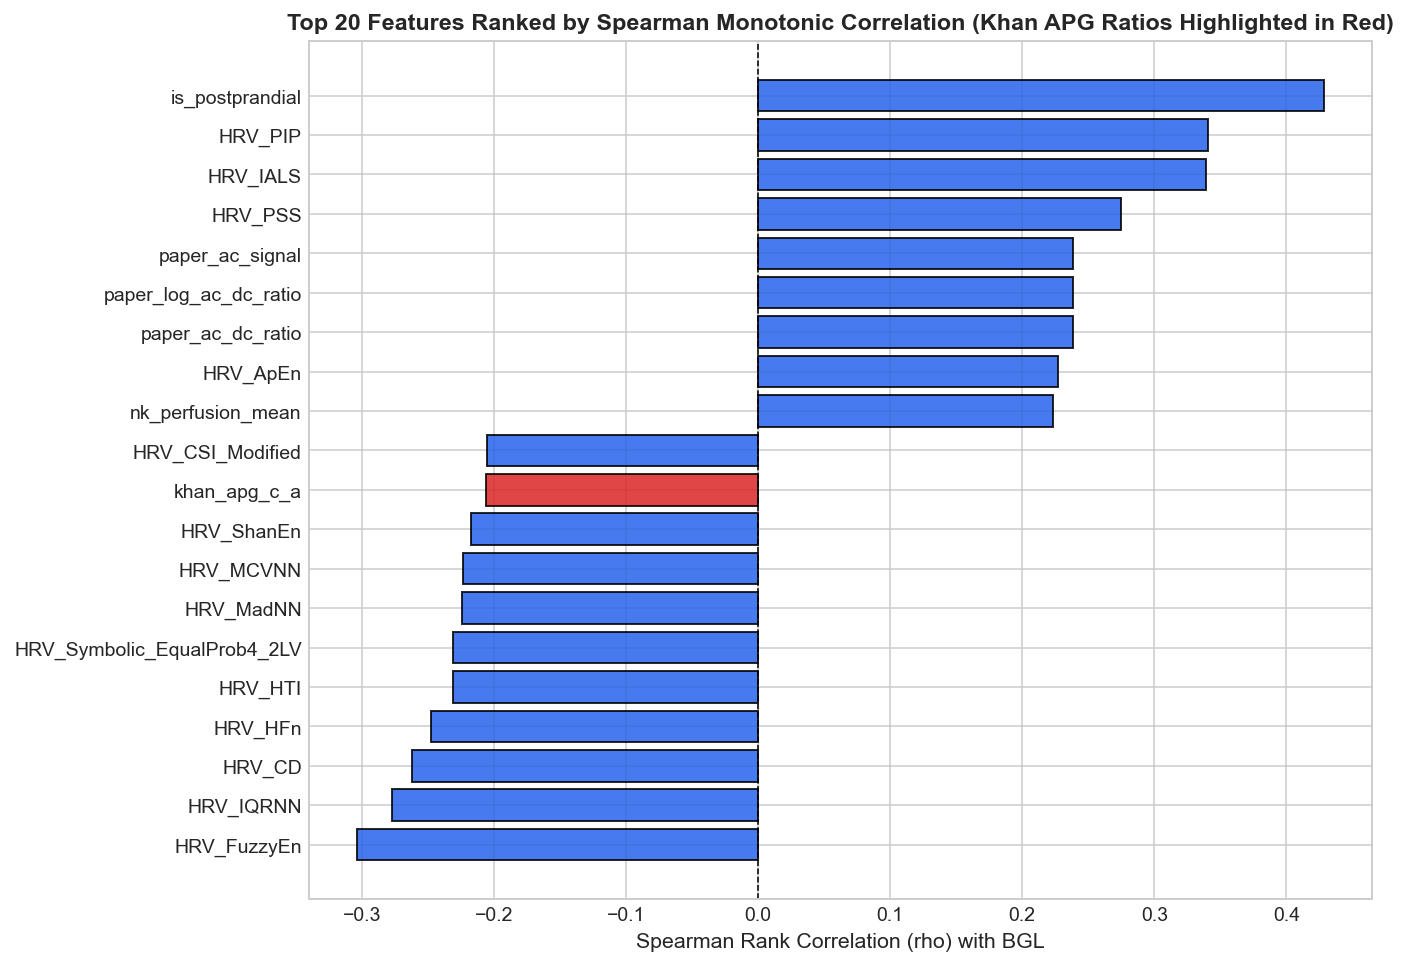

In [25]:
# ── Feature Correlation Ranking (Spearman rho) ──
y_full = df_khan_features['bgl_mgdl'].values
corr_records = []
for feat in ALL_CANDIDATE_FEATURES:
    vals = df_khan_features[feat].values
    valid_mask = ~np.isnan(vals) & ~np.isnan(y_full)
    if np.sum(valid_mask) > 5 and np.std(vals[valid_mask]) > 1e-9:
        r_p, p_p = pearsonr(vals[valid_mask], y_full[valid_mask])
        r_s, p_s = spearmanr(vals[valid_mask], y_full[valid_mask])
        if feat in DEMOGRAPHIC_METADATA_COLS: cat = 'Demographic'
        elif feat in KHAN_APG_RATIOS: cat = 'Khan APG Ratio'
        elif feat in AC_DC_PERFUSION_FEATURES: cat = 'AC/DC Perfusion'
        else: cat = 'HRV/Spectral'
        corr_records.append({
            'Feature': feat, 'Category': cat, 'Pearson r': r_p, 'Pearson p-val': p_p,
            'Spearman rho': r_s, 'Spearman p-val': p_s, 'Abs Spearman rho': abs(r_s)
        })

corr_df = pd.DataFrame(corr_records).sort_values(by='Abs Spearman rho', ascending=False).reset_index(drop=True)
print('=== Top 25 Features Ranked by Spearman Monotonic Correlation (rho) ===')
display(corr_df.head(25))

plt.figure(figsize=(10, 7))
top_plot_df = corr_df.head(20).sort_values(by='Spearman rho', ascending=True)
colors = ['#dc2626' if cat == 'Khan APG Ratio' else '#2563eb' for cat in top_plot_df['Category']]
plt.barh(top_plot_df['Feature'], top_plot_df['Spearman rho'], color=colors, alpha=0.85, edgecolor='k')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Spearman Rank Correlation (rho) with BGL', fontsize=11)
plt.title('Top 20 Features Ranked by Spearman Monotonic Correlation (Khan APG Ratios Highlighted in Red)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


In [26]:
# ── Zero-Leakage Fold-Level Feature Selection & Cross-Validation ──
def select_features_on_fold_train(X_tr_df, y_tr, feature_pool, max_features=10, collinear_threshold=0.85, method='spearman'):
    imp = SimpleImputer(strategy='mean')
    X_tr_imp_vals = imp.fit_transform(X_tr_df[feature_pool])
    X_tr_imp = pd.DataFrame(X_tr_imp_vals, columns=feature_pool, index=X_tr_df.index)
    
    corrs = X_tr_imp.apply(lambda col: col.corr(pd.Series(y_tr, index=X_tr_df.index), method=method))
    sorted_corrs = corrs.abs().sort_values(ascending=False)
    candidate_feats = sorted_corrs.head(30).index.tolist()
    
    corr_matrix = X_tr_imp[candidate_feats].corr(method=method).abs()
    to_drop = set()
    for i in range(len(candidate_feats)):
        col_i = candidate_feats[i]
        if col_i in to_drop: continue
        for j in range(i + 1, len(candidate_feats)):
            col_j = candidate_feats[j]
            if col_j in to_drop: continue
            if corr_matrix.loc[col_i, col_j] > collinear_threshold:
                if abs(corrs[col_i]) >= abs(corrs[col_j]):
                    to_drop.add(col_j)
                else:
                    to_drop.add(col_i)
    return [f for f in candidate_feats if f not in to_drop][:max_features]

X_full_df = df_khan_features[ALL_CANDIDATE_FEATURES].copy().replace([np.inf, -np.inf], np.nan)
y = df_khan_features['bgl_mgdl'].values
groups = df_khan_features['participant_id'].values

gkf = GroupKFold(n_splits=5)
logo = LeaveOneGroupOut()

gkf_folds_data = []
for train_idx, val_idx in gkf.split(X_full_df, y, groups):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, ALL_CANDIDATE_FEATURES, method='spearman')
    gkf_folds_data.append((train_idx, val_idx, fold_feats))

logo_folds_data = []
for train_idx, val_idx in logo.split(X_full_df, y, groups):
    X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
    fold_feats = select_features_on_fold_train(X_tr_df, y_tr, ALL_CANDIDATE_FEATURES, method='spearman')
    logo_folds_data.append((train_idx, val_idx, fold_feats))

print(f"✓ Prepared {len(gkf_folds_data)} GroupKFold splits & {len(logo_folds_data)} LOGOCV Subject splits using Spearman Selection.")

models = {
    'Linear Regression (OLS)': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0, random_state=42),
    'Lasso Regression': Lasso(alpha=0.1, random_state=42),
    'ElasticNet': ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, max_depth=4, max_features='sqrt', random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'Extra Trees': ExtraTreesRegressor(random_state=42)
}
if has_catboost:
    models['CatBoost'] = cb.CatBoostRegressor(verbose=0, random_state=42)
if has_xgboost:
    models['XGBoost'] = xgb.XGBRegressor(random_state=42)

strict_results = []
for model_name, model in models.items():
    g_maes, g_rmses, g_r2s = [], [], []
    for train_idx, val_idx, fold_feats in gkf_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        if isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        model.fit(X_tr_imp, y_tr)
        preds = model.predict(X_va_imp)
        g_maes.append(mean_absolute_error(y_va, preds))
        g_rmses.append(np.sqrt(mean_squared_error(y_va, preds)))
        g_r2s.append(r2_score(y_va, preds))

    logo_preds = np.zeros(len(y))
    for train_idx, val_idx, fold_feats in logo_folds_data:
        X_tr_df, y_tr = X_full_df.iloc[train_idx].copy(), y[train_idx]
        X_va_df, y_va = X_full_df.iloc[val_idx].copy(), y[val_idx]
        imp = SimpleImputer(strategy='mean')
        X_tr_imp = imp.fit_transform(X_tr_df[fold_feats])
        X_va_imp = imp.transform(X_va_df[fold_feats])
        if isinstance(model, (LinearRegression, Ridge, Lasso, ElasticNet)):
            scaler = StandardScaler()
            X_tr_imp = scaler.fit_transform(X_tr_imp)
            X_va_imp = scaler.transform(X_va_imp)
        model.fit(X_tr_imp, y_tr)
        logo_preds[val_idx] = model.predict(X_va_imp)

    logo_mae = mean_absolute_error(y, logo_preds)
    logo_rmse = np.sqrt(mean_squared_error(y, logo_preds))
    logo_r2 = r2_score(y, logo_preds)

    strict_results.append({
        'Algorithm': model_name,
        '5F-GroupKF MAE': f'{np.mean(g_maes):.2f}',
        '5F-GroupKF RMSE': f'{np.mean(g_rmses):.2f}',
        '5F-GroupKF R^2': f'{np.mean(g_r2s):.3f}',
        'LOGOCV MAE': f'{logo_mae:.2f}',
        'LOGOCV RMSE': f'{logo_rmse:.2f}',
        'LOGOCV R^2': f'{logo_r2:.3f}'
    })

summary_df = pd.DataFrame(strict_results)
print('=== Strict Zero-Leakage Cross-Validation Evaluation Summary (Khan APG Integration) ===')
display(summary_df)


✓ Prepared 5 GroupKFold splits & 85 LOGOCV Subject splits using Spearman Selection.
=== Strict Zero-Leakage Cross-Validation Evaluation Summary (Khan APG Integration) ===


,Algorithm,5F-GroupKF MAE,5F-GroupKF RMSE,5F-GroupKF R^2,LOGOCV MAE,LOGOCV RMSE,LOGOCV R^2
0,Linear Regression (OLS),37.07,44.28,0.013,35.80,43.78,0.120
1,Ridge Regression,36.89,44.03,0.027,35.79,43.69,0.124
2,Lasso Regression,36.91,44.11,0.023,35.81,43.74,0.122
3,ElasticNet,36.47,43.47,0.057,35.79,43.45,0.134
4,Random Forest,36.27,43.33,0.087,37.02,44.31,0.099
5,Gradient Boosting,36.11,44.53,0.028,35.69,44.94,0.073
6,Extra Trees,34.97,43.47,0.050,34.42,44.55,0.089
7,CatBoost,34.41,42.32,0.130,34.72,42.85,0.157
8,XGBoost,39.33,47.48,-0.145,34.64,44.83,0.078
